In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV

# Забираем все модели из scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

import warnings
warnings.filterwarnings('ignore')

# --- ГЛОБАЛЬНАЯ ФИКСАЦИЯ SEED ---
SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything()
print("Библиотеки загружены (только sklearn!), глобальный SEED зафиксирован!")

Библиотеки загружены (только sklearn!), глобальный SEED зафиксирован!


In [2]:
# Загружаем обновленные данные с новыми фичами
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
X_val = pd.read_csv('../data/processed/X_val.csv')
y_val = pd.read_csv('../data/processed/y_val.csv').squeeze()
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Кодируем строковые переменные (One-Hot Encoding)
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, drop_first=True).reindex(columns=X_train_encoded.columns, fill_value=0)
X_test_encoded = pd.get_dummies(X_test, drop_first=True).reindex(columns=X_train_encoded.columns, fill_value=0)

# Масштабируем (нужно для PCA и некоторых моделей)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

--- Уменьшение размерности (PCA) ---


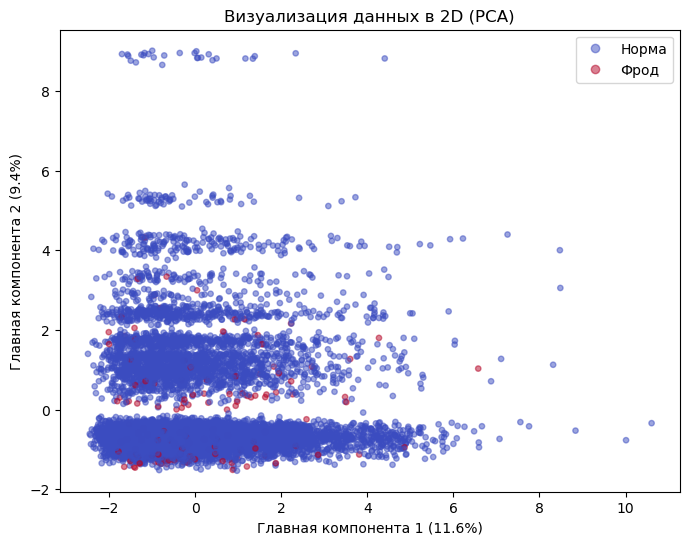

Вывод по PCA: Классы сильно перемешаны. Простых линейных зависимостей недостаточно для их разделения. Необходимы мощные нелинейные алгоритмы (бустинги).


In [3]:
print("--- Уменьшение размерности (PCA) ---")
# Проецируем многомерные данные на 2 компоненты для визуализации
pca = PCA(n_components=2, random_state=SEED)
# Обучаем на сэмпле (чтобы график не был просто сплошным пятном и считался быстрее)
sample_idx = np.random.choice(X_train_scaled.shape[0], 10000, replace=False)
X_pca = pca.fit_transform(X_train_scaled[sample_idx])
y_pca = y_train.iloc[sample_idx]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pca, cmap='coolwarm', alpha=0.5, s=15)
plt.title('Визуализация данных в 2D (PCA)')
plt.xlabel(f'Главная компонента 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Главная компонента 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(handles=scatter.legend_elements()[0], labels=['Норма', 'Фрод'])
plt.show()

print("Вывод по PCA: Классы сильно перемешаны. Простых линейных зависимостей недостаточно для их разделения. Необходимы мощные нелинейные алгоритмы (бустинги).")

In [4]:
results = []

def evaluate_and_log(model_name, y_true, y_pred, y_proba):
    res = {
        'Model': model_name,
        'PR-AUC': average_precision_score(y_true, y_proba),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'F1-score': f1_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred)
    }
    results.append(res)
    return res

# 1. Logistic Regression (Baseline)
print("Обучение Logistic Regression...")
lr = LogisticRegression(class_weight='balanced', random_state=SEED, max_iter=500)
lr.fit(X_train_scaled, y_train)
evaluate_and_log('LogReg (Baseline)', y_val, lr.predict(X_val_scaled), lr.predict_proba(X_val_scaled)[:, 1])

# 2. Decision Tree (Обычное дерево)
print("Обучение Decision Tree...")
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=SEED)
dt.fit(X_train_encoded, y_train)
evaluate_and_log('Decision Tree', y_val, dt.predict(X_val_encoded), dt.predict_proba(X_val_encoded)[:, 1])

# 3. Random Forest (Ансамбль)
print("Обучение Random Forest...")
rf = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced', random_state=SEED, n_jobs=-1)
rf.fit(X_train_encoded, y_train)
evaluate_and_log('Random Forest', y_val, rf.predict(X_val_encoded), rf.predict_proba(X_val_encoded)[:, 1])

# 4. HistGradientBoosting (Встроенный аналог LightGBM)
print("Обучение HistGradientBoosting...")
# Для этого бустинга балансировка классов задается через веса сэмплов
neg_class = (y_train == 0).sum()
pos_class = (y_train == 1).sum()
scale_weight = neg_class / pos_class
sample_weights = np.where(y_train == 1, scale_weight, 1.0)

hgb = HistGradientBoostingClassifier(random_state=SEED, max_iter=100)
hgb.fit(X_train_encoded, y_train, sample_weight=sample_weights)
evaluate_and_log('HistGradientBoosting', y_val, hgb.predict(X_val_encoded), hgb.predict_proba(X_val_encoded)[:, 1])

# Вывод таблицы
results_df = pd.DataFrame(results).sort_values(by='PR-AUC', ascending=False)
display(results_df.round(4))

Обучение Logistic Regression...
Обучение Decision Tree...
Обучение Random Forest...
Обучение HistGradientBoosting...


,Model,PR-AUC,ROC-AUC,F1-score,Recall,Precision
0,LogReg (Baseline),0.2834,0.8409,0.1175,0.7690,0.0636
3,HistGradientBoosting,0.2549,0.8289,0.1980,0.6486,0.1169
2,Random Forest,0.2122,0.8115,0.2390,0.5650,0.1516
1,Decision Tree,0.2087,0.7355,0.1751,0.5937,0.1027


In [5]:
print("--- Подбор гиперпараметров для Random Forest ---")

# Пространство поиска для тюнинга
param_distributions = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=5,                    # Проверяем 5 случайных комбинаций
    scoring='average_precision', # Тюним под нашу главную метрику (PR-AUC)
    cv=3,                        # Кросс-валидация на 3 фолда
    verbose=1,
    random_state=SEED,
    n_jobs=-1
)

print("Запуск подбора (это может занять пару минут)...")
random_search.fit(X_train_encoded, y_train)

print("\nЛучшие параметры:", random_search.best_params_)
best_model = random_search.best_estimator_

# Оцениваем лучшую модель
evaluate_and_log('Random Forest (Tuned)', y_val, best_model.predict(X_val_encoded), best_model.predict_proba(X_val_encoded)[:, 1])

# Итоговая таблица
final_results_df = pd.DataFrame(results).sort_values(by='PR-AUC', ascending=False).reset_index(drop=True)
display(final_results_df.round(4))

import joblib
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/best_rf_tuned.pkl')
print("\nЛучшая модель сохранена в ../models/best_rf_tuned.pkl")

--- Подбор гиперпараметров для Random Forest ---
Запуск подбора (это может занять пару минут)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Лучшие параметры: {'n_estimators': 150, 'min_samples_split': 10, 'max_depth': 10}


,Model,PR-AUC,ROC-AUC,F1-score,Recall,Precision
0,LogReg (Baseline),0.2834,0.8409,0.1175,0.7690,0.0636
1,HistGradientBoosting,0.2549,0.8289,0.1980,0.6486,0.1169
2,Random Forest,0.2122,0.8115,0.2390,0.5650,0.1516
3,Decision Tree,0.2087,0.7355,0.1751,0.5937,0.1027
4,Random Forest (Tuned),0.2018,0.8213,0.2407,0.5615,0.1532



Лучшая модель сохранена в ../models/best_rf_tuned.pkl
